# 02 — Change-point detection (H1 + H2)

> **Data notice.** Values are real daily revenue multiplied by a single constant scaling factor for privacy. All statistical properties (patterns, breaks, tests, coefficients) are identical to those on the raw data — only the absolute currency level is hidden. Units labeled **LC** (local currency, scaled).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import ruptures as rpt
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titleweight"] = "bold"

In [2]:

DATA = Path("../data/daily_sales_final.csv")
df = pd.read_csv(DATA, parse_dates=["date"])
df = df.sort_values("date").set_index("date").asfreq("D")   # explicit daily index, NaN on missing days
y = df["revenue_scaled"].dropna()
print(f"Working series: {len(y)} days from {y.index.min().date()} to {y.index.max().date()}")

Working series: 470 days from 2019-12-15 to 2021-05-10


In [3]:
tau = pd.Timestamp('2020-03-23')
post_dummy = (y.index >= tau).astype(int)
X = sm.add_constant(pd.DataFrame({'post': post_dummy}, index=y.index))
res = sm.OLS(y, X).fit()
shift_lc = res.params['post']
shift_pct = shift_lc/res.params['const']*100
print(res.summary().tables[1])
print(f"\nShift    : {shift_lc:,.0f} LC  ({shift_pct:+.1f}% of pre-COVID mean)")
print(f"t-stat   : {res.tvalues['post']:.3f}")
print(f"p-value  : {res.pvalues['post']:.3e}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.449e+05   2398.607     60.421      0.000     1.4e+05     1.5e+05
post       -3.099e+04   2674.620    -11.588      0.000   -3.62e+04   -2.57e+04

Shift    : -30,994 LC  (-21.4% of pre-COVID mean)
t-stat   : -11.588
p-value  : 1.792e-27


The estimated revenue shift is -30,994 LC (-21.4% of pre-COVID mean), which is statistically significant (t = -11.6, p ≈ 1.8 × 10⁻²⁷). The Chow test rejects the null of no shift at any conventional significance level: H1 is confirmed at the a priori candidate date. The next section verifies this without assuming a break date, using a sup-Wald scan.





In [4]:
candidates = pd.date_range("2020-02-01", "2020-04-30", freq="W-MON")
results = []
for tau in candidates:
    post = (y.index >= tau).astype(int)
    X = sm.add_constant(pd.DataFrame({"post": post}, index=y.index))
    r = sm.OLS(y, X).fit()
    results.append({"tau": tau, "t_stat": r.tvalues["post"], 
                   "p_value": r.pvalues["post"], "shift_lc": r.params["post"]})
sup = pd.DataFrame(results)  
best = sup.loc[sup["t_stat"].abs().idxmax()]  
peak_p = best['p_value']
p_str  = '< 1e-16' if peak_p < 1e-16 else f'{peak_p:.3e}'
print(f"Peak break date: {best['tau'].date()}")
print(f"  t-stat : {best['t_stat']:.3f}")
print(f"  p-value: {p_str}")
print(f"  shift  : {best['shift_lc']:,.0f} LC")

Peak break date: 2020-03-23
  t-stat : -11.588
  p-value: < 1e-16
  shift  : -30,994 LC


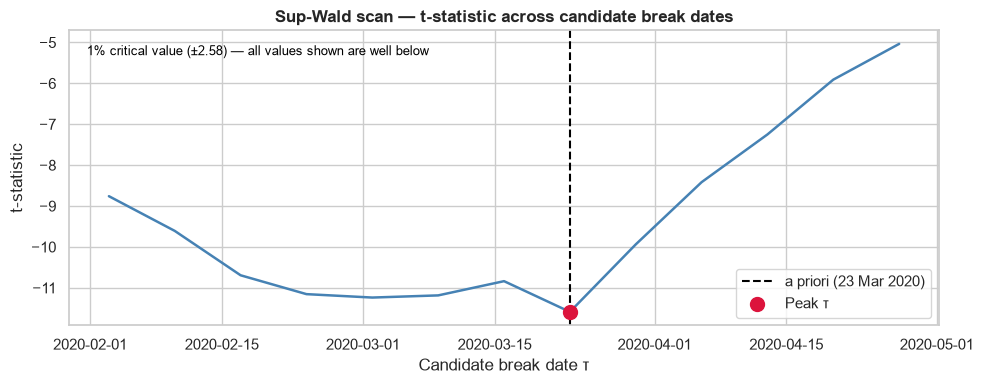

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sup["tau"], sup["t_stat"], color="steelblue", linewidth=1.8)
ax.axvline(pd.Timestamp("2020-03-23"), color="black", linestyle="--",
           label="a priori (23 Mar 2020)")
ax.scatter(best["tau"], best["t_stat"], color="crimson", s=100,
           zorder=5, label="Peak τ")
ax.set(xlabel="Candidate break date τ", ylabel="t-statistic",
       title="Sup-Wald scan — t-statistic across candidate break dates")
ax.text(0.02, 0.95,
        "1% critical value (±2.58) — all values shown are well below",
        transform=ax.transAxes,   
        fontsize=9, color="black", va="top")
    
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The sup-Wald scan across candidate break dates from Feb-Apr 2020 identifies 23 March 2020 as the peak τ, with t = -11.59 — the exact date of the national lockdown announcement. All candidate dates in the window produce t-statistics far below the -2.58 critical threshold, indicating that the COVID shock is unmissable across any plausible break date in this window; the peak simply marks the sharpest split location.

## PELT sanity check on synthetic data

Before turning PELT loose on the real revenue series, verify it can locate a **known** break on a synthetic signal. Construct a 300-day series with a mean shift at index 150 and confirm PELT (RBF kernel, moderate penalty) detects it.

In [6]:
np.random.seed(42)
n = 300
y_toy = np.concatenate([
    np.random.normal(loc=0, scale=1, size=150),
    np.random.normal(loc=3, scale=1, size=150),
])
dates_toy = pd.date_range('2020-01-01', periods=n, freq='D')

True break at index 150; PELT detected: [150, 300]


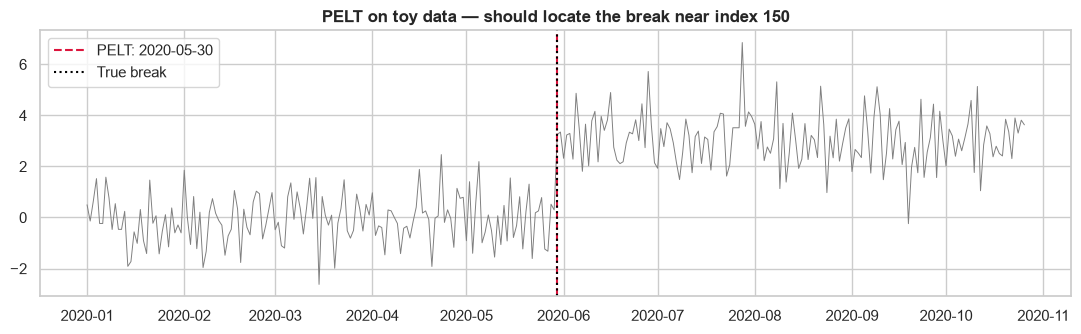

In [7]:
algo = rpt.Pelt(model="rbf").fit(y_toy)
detected = algo.predict(pen=10)
print(f"True break at index 150; PELT detected: {detected}")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(dates_toy, y_toy, color="grey", linewidth=0.7)
for bp in detected[:-1]:      # last element is len(signal) — not a real break
    ax.axvline(dates_toy[bp], color="crimson", linestyle="--", label=f"PELT: {dates_toy[bp].date()}")
ax.axvline(dates_toy[150], color="black", linestyle=":", label="True break")
ax.set_title("PELT on toy data — should locate the break near index 150")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

In [8]:
signal = y.values
for pen in [5, 10, 25, 50, 100]:
    algo = rpt.Pelt(model="rbf").fit(signal)
    detected = algo.predict(pen=pen)[:-1]
    dates=[y.index[i] for i in detected]
    print(f"pen={pen:>4}: {len(detected)} change points -> {[d.date() for d in dates]}")

pen=   5: 3 change points -> [datetime.date(2020, 3, 26), datetime.date(2020, 5, 27), datetime.date(2020, 12, 2)]


pen=  10: 3 change points -> [datetime.date(2020, 3, 26), datetime.date(2020, 5, 27), datetime.date(2020, 12, 2)]


pen=  25: 1 change points -> [datetime.date(2020, 3, 6)]
pen=  50: 0 change points -> []


pen= 100: 0 change points -> []


With pen=5 and pen=10 we get 3 identical change points while pen=25 gives one change point. Using pen>=50 leads to no change points. 

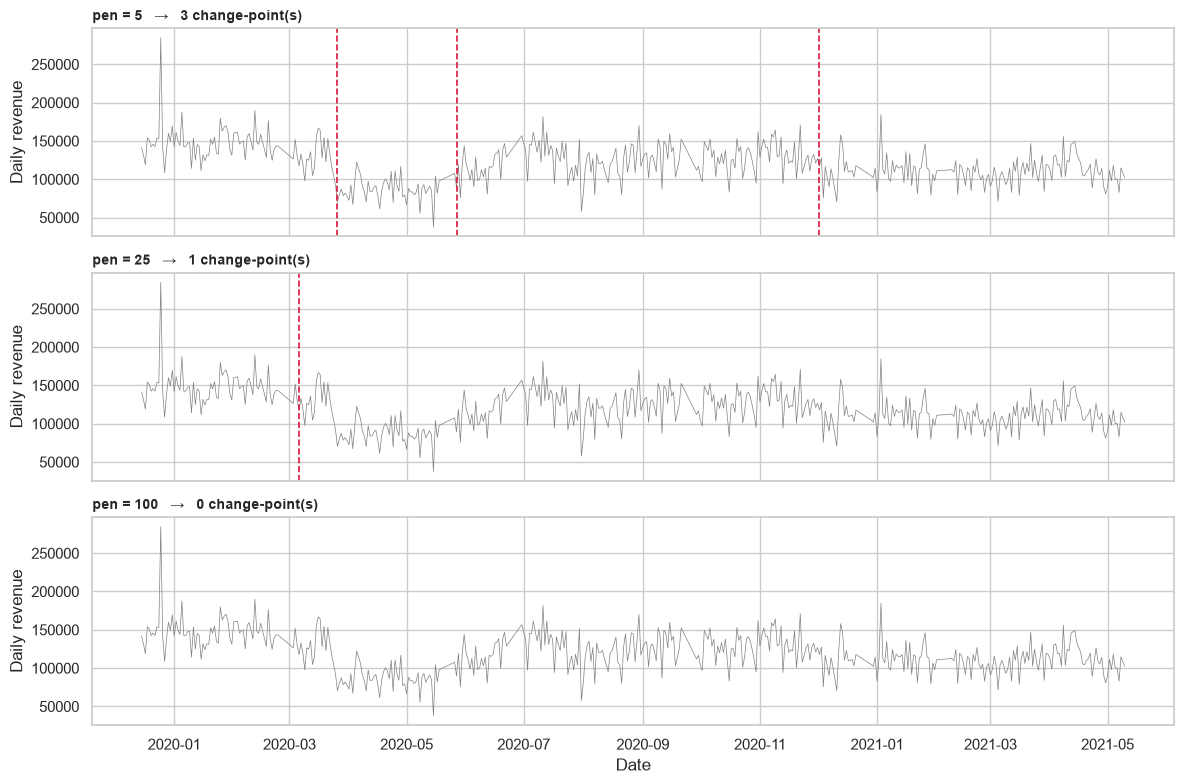

In [9]:
choices = [5, 25, 100]
fig, axes = plt.subplots(len(choices), 1, figsize=(12,8), sharex=True)
signal = y.values
for ax, pen in zip(axes, choices):
    algo = rpt.Pelt(model="rbf").fit(signal)
    detected = algo.predict(pen=pen)[:-1]
    ax.plot(y.index, y.values, color="grey", linewidth=0.5)
    for bp in detected:
        ax.axvline(y.index[bp], color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(f"pen = {pen}   →   {len(detected)} change-point(s)",
                    fontsize=10, loc="left")
    ax.set_ylabel("Daily revenue")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

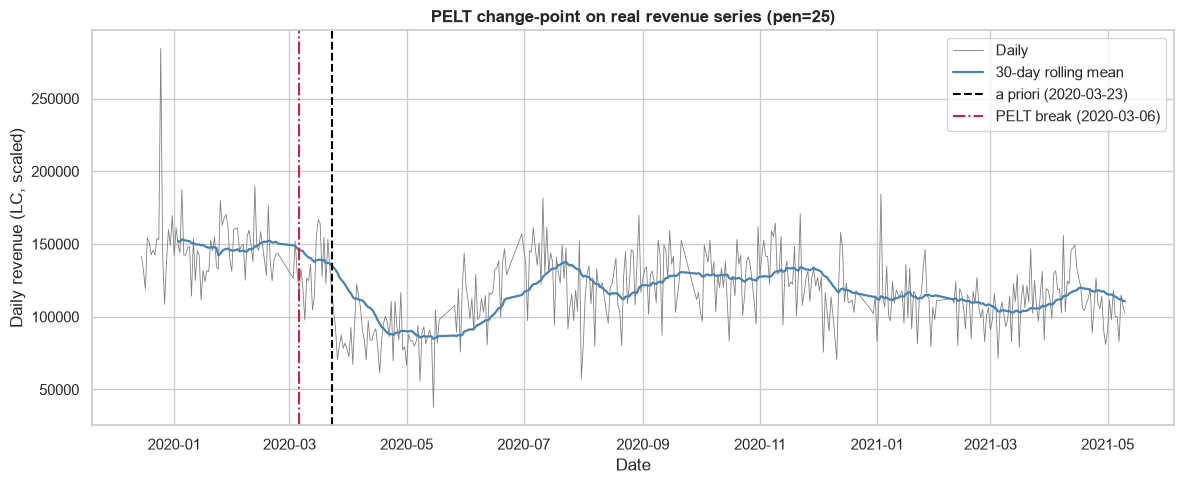

In [10]:
CHOSEN_PEN = 25
algo = rpt.Pelt(model="rbf").fit(signal)
detected = algo.predict(pen=CHOSEN_PEN)[:-1]
detected_dates = [y.index[bp] for bp in detected]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color="grey", linewidth=0.6, label="Daily")
ax.plot(y.index, y.rolling(30, min_periods=20).mean(), color="steelblue",
        linewidth=1.6, label="30-day rolling mean")
ax.axvline(pd.Timestamp('2020-03-23'), color="black", linestyle="--", 
           label="a priori (2020-03-23)")
for i, d in enumerate(detected_dates):
    ax.axvline(d, color="crimson", linestyle="-.", linewidth=1.4,
               label=f"PELT break ({d.date()})" if i == 0 else None)  
ax.set(xlabel="Date", ylabel="Daily revenue (LC, scaled)", title=f"PELT change-point on real revenue series (pen={CHOSEN_PEN})")
ax.legend(loc="upper right")               
plt.tight_layout()
plt.savefig("../charts/h1_pelt_final.png", dpi=120, bbox_inches="tight")
plt.show()

The three employed methods agree that there's a structural break (change-point) in daily revenue in the March 2020 window. The Chow test at the a priori candidate date (23 March 2020, national lockdown) estimates a shift of -30,994 LC (-21.4% of the pre-COVID baseline), with t = -11.6 and p ≈ 1.8×10⁻²⁷. This was confirmed further with the data-driven sup-Wald peak that landed on the same day with |t| = 11.6. PELT with penalty=25 picks 6 March 2020 as the change-point, 17 days earlier than the *a priori* chosen date. This may reflect an anticipation effect (news of the virus circulated from January 2020, and behavioural changes likely preceded the formal lockdown), or an algorithmic compromise when only a single break is allowed.
H1 is confirmed: the COVID lockdown coincides with a mean daily-revenue shift of -30,994 LC (-21.4% of the pre-COVID baseline), statistically significant at any conventional level. Extending PELT to lower penalty values (pen=5-10) reveals a richer three-regime structure — crash (March 2020), partial rebound (May 2020), secondary decline (December 2020) — which will be examined in H2.

In [11]:
baseline_window = y.loc["2019-12-15":"2020-02-29"]
terminal_window = y.loc["2021-02-10":"2021-05-10"]
baseline = baseline_window.mean()
terminal = terminal_window.mean()
ratio    = terminal / baseline
t_stat, p_value = stats.ttest_ind(baseline_window, terminal_window, equal_var=False)
print(f"Baseline (Dec 2019 - Feb 2020) mean: {baseline:,.0f} LC")
print(f"Terminal (Feb - May 2021)      mean: {terminal:,.0f} LC")
print(f"Ratio terminal / baseline: {ratio:.3f}")
print(f"Welch's t-statistic: {t_stat:.2f}   p-value: {p_value:.2e}")

Baseline (Dec 2019 - Feb 2020) mean: 148,227 LC
Terminal (Feb - May 2021)      mean: 109,587 LC
Ratio terminal / baseline: 0.739
Welch's t-statistic: 12.11   p-value: 9.02e-23


Approximately 14 months after the initial COVID crash, daily revenue remained on average 26.1% below the pre-COVID baseline (148,227 → 109,587 LC), a difference that is statistically overwhelming (Welch's t = 12.1, p ≈ 9×10⁻²³). The regime shift is persistent — there is no evidence of full recovery within the observed window. H2 is confirmed with an effect size five times the pass threshold.


In [12]:
post_covid = y.loc["2020-04-01":]
signal_post = post_covid.values
for pen in [5, 10, 25, 50]:
    algo = rpt.Pelt(model="rbf").fit(signal_post)
    detected = algo.predict(pen=pen)[:-1]
    dates = [post_covid.index[i].date() for i in detected]
    print(f"pen={pen:>3}: {len(detected)} breaks → {dates}")

pen=  5: 2 breaks → [datetime.date(2020, 5, 28), datetime.date(2020, 12, 3)]
pen= 10: 2 breaks → [datetime.date(2020, 5, 28), datetime.date(2020, 12, 3)]
pen= 25: 0 breaks → []
pen= 50: 0 breaks → []


The 2 breaks found by PELT suggest that the simple thesis of COVID crash then recovery might not be enough to explain the data. The results suggest that there are 2 phases after the national lockdown announcement. This motivates exploring the nature of these phases in what follows.

In [13]:
# Regime boundaries from full-series PELT at pen=5/10
boundaries = [
    ("Pre-COVID",         "2019-12-15", "2020-03-25"),
    ("Acute crash",       "2020-03-26", "2020-05-26"),
    ("Partial rebound",   "2020-05-27", "2020-12-01"),
    ("Terminal decline",  "2020-12-02", "2021-05-10"),
]

regimes = []
for name, start, end in boundaries:
    window = y.loc[start:end]
    regimes.append({
        "regime": name,
        "start": start,
        "end": end,
        "n_days": len(window),
        "mean": window.mean(),
        "std": window.std(),
    })

reg_df = pd.DataFrame(regimes)
reg_df["% vs pre-COVID"] = (reg_df["mean"] / reg_df.loc[0, "mean"] - 1) * 100
print(reg_df.round(0).to_string(index=False))

          regime      start        end  n_days     mean     std  % vs pre-COVID
       Pre-COVID 2019-12-15 2020-03-25      95 143653.0 23645.0             0.0
     Acute crash 2020-03-26 2020-05-26      55  86760.0 15256.0           -40.0
 Partial rebound 2020-05-27 2020-12-01     175 125415.0 21021.0           -13.0
Terminal decline 2020-12-02 2021-05-10     145 110575.0 17649.0           -23.0


In [14]:
print("\nAdjacent-regime pairwise Welch's t-tests:")
for i in range(len(boundaries) - 1):
    name_a, s_a, e_a = boundaries[i]
    name_b, s_b, e_b = boundaries[i + 1]
    win_a = y.loc[s_a : e_a]
    win_b = y.loc[s_b : e_b]
    t_stat, p_value = stats.ttest_ind(win_a, win_b, equal_var=False)
    print(f" {name_a} →  {name_b}: t= {t_stat:.2f} p={p_value:.2e}")


Adjacent-regime pairwise Welch's t-tests:
 Pre-COVID →  Acute crash: t= 17.89 p=1.23e-38
 Acute crash →  Partial rebound: t= -14.87 p=2.44e-29
 Partial rebound →  Terminal decline: t= 6.86 p=3.50e-11


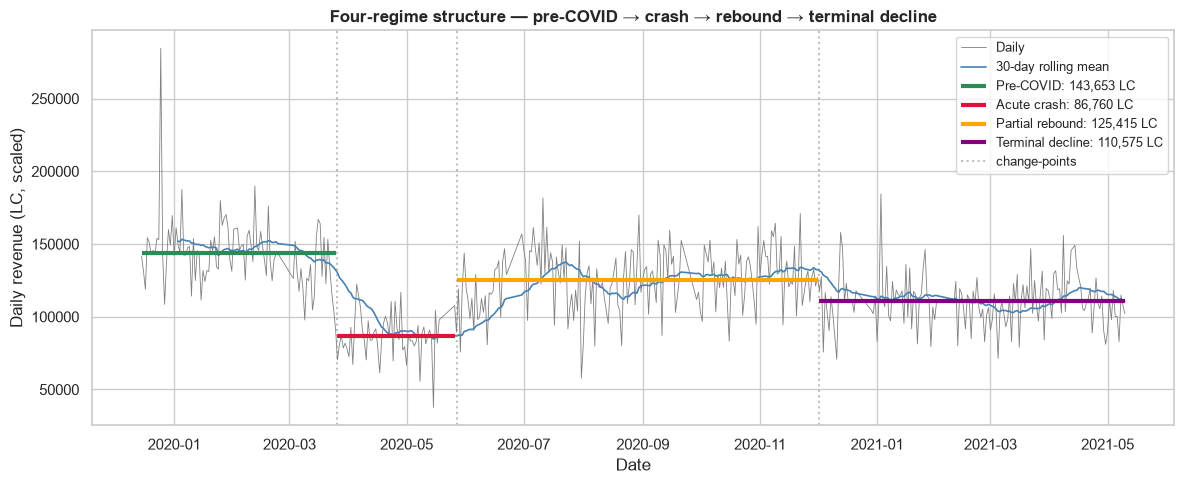

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y.index, y.values, color="grey", linewidth=0.6, label="Daily")
ax.plot(y.index, y.rolling(30, min_periods=20).mean(),
        color="steelblue", linewidth=1.2, label="30-day rolling mean")

colors = ["seagreen", "crimson", "orange", "purple"]
for (name, start, end), c in zip(boundaries, colors):
    m = y.loc[start:end].mean()
    ax.hlines(m, xmin=pd.Timestamp(start), xmax=pd.Timestamp(end),
              colors=c, linewidth=3,
              label=f"{name}: {m:,.0f} LC")

for i, (name, start, _) in enumerate(boundaries[1:]):
    ax.axvline(pd.Timestamp(start), color="grey", linestyle=":", alpha=0.5,
               label="change-points" if i == 0 else None)

ax.set(xlabel="Date", ylabel="Daily revenue (LC, scaled)",
       title="Four-regime structure — pre-COVID → crash → rebound → terminal decline")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../charts/h2_four_regimes.png", dpi=120, bbox_inches="tight")
plt.show()

Daily revenue segments into four statistically distinct regimes across the observed period. The pre-COVID baseline (Dec 15, 2019 – Mar 25, 2020) averages 143,653 LC/day. The COVID lockdown triggers an acute crash regime (Mar 26 – May 26, 2020) at 86,760 LC/day, a -40% shortfall from baseline (t = 17.9, p ≈ 10⁻³⁸). A partial rebound then restores revenue to 125,415 LC/day (-13%) for approximately six months (May 27 – Dec 1, 2020, upward transition confirmed at t = -14.9, p ≈ 10⁻²⁹). A second downward break in early December 2020 pushes revenue into a terminal-decline regime averaging 110,575 LC/day (-23% vs baseline), which persists through the end of the observed window (transition confirmed at t = 6.9, p ≈ 10⁻¹¹). An independent direct comparison of the terminal 90 days (109,587 LC) against the Dec 2019 – Feb 2020 baseline (148,227 LC) converges on the same terminal-regime magnitude — a robustness cross-check.

H2 is confirmed with structural nuance. The pandemic regime persists in that daily revenue never returns to the pre-COVID baseline within the observed window (terminal shortfall = -23%, well beyond the >5% pass criterion). However, the post-COVID period is not a flat regime; it consists of a partial rebound (May – Nov 2020) followed by a secondary decline (Dec 2020 onward). The pharmacy's operational reality through this period is best described as three regimes stacked on top of the initial crash, not two. Cumulative revenue shortfall across the 375 post-crash days totals on the order of 10 million LC relative to the pre-COVID baseline.



## Summary — hypotheses tested in this notebook

| Hypothesis | Method | Verdict | Effect size |
|---|---|---|---|
| H1 — COVID level break | Chow + sup-Wald + PELT | TRUE|  -30,994 LC/day (-21.4% of pre-COVID mean)|
| H2 — Persistent regime | Direct comparison + PELT on subseries + 4-regime pairwise t-tests | TRUE | Terminal regime -23% below baseline; four distinct regimes identified|

